In [2]:
import pandas as pd 
import numpy as np

In [ ]:
df = pd.read_csv("diabetes.csv")
df.head()

all about columns
(Pregnancies)How many times the woman has been pregnant.
(Glucose)Amount of glucose (sugar) in the blood.
(BloodPressure) Blood pressure level. 
(SkinThickness ) It helps to know body fat ,Bigger number = more fat.  
(Insulin) Amount of insulin in the blood.Insulin helps control sugar.
(BMI) "Body Mass Index" Shows if a person is underweight, normal, overweight, or obese.
(DiabetesPedigreeFunction) This tells how much diabetes runs in the family.
(Age) Age of the person in years.
(Outcome)
0 = person does not have diabetes.
1 = person has diabetes.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
def remove_outliers_iqr(df):
    for col in df.select_dtypes(include=np.number).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower_limit) & (df[col] <= upper_limit)]
    return df

df_clean = remove_outliers_iqr(df)


In [ ]:
import matplotlib.pyplot as plt

C:\Users\Nilesh\AppData\Local\Temp\ipykernel_3136\2410515165.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df['Outcome']==0]['Age'],


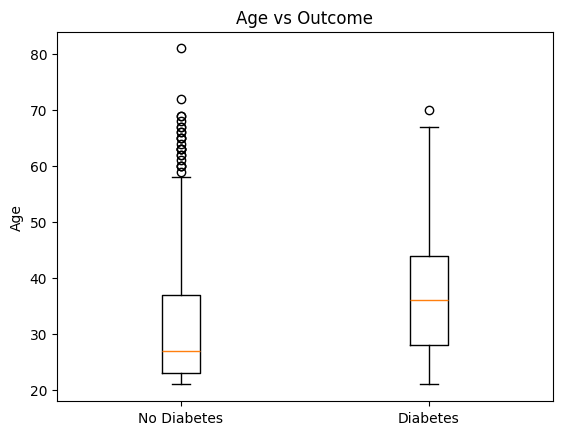

In [ ]:
plt.boxplot([df[df['Outcome']==0]['Age'],
             df[df['Outcome']==1]['Age']],
            labels=['No Diabetes', 'Diabetes'])
plt.ylabel("Age")
plt.title("Age vs Outcome")
plt.show()


People with diabetes are generally older than people without diabetes.                  
The boxplot shows that age increases the chances of having diabetes.

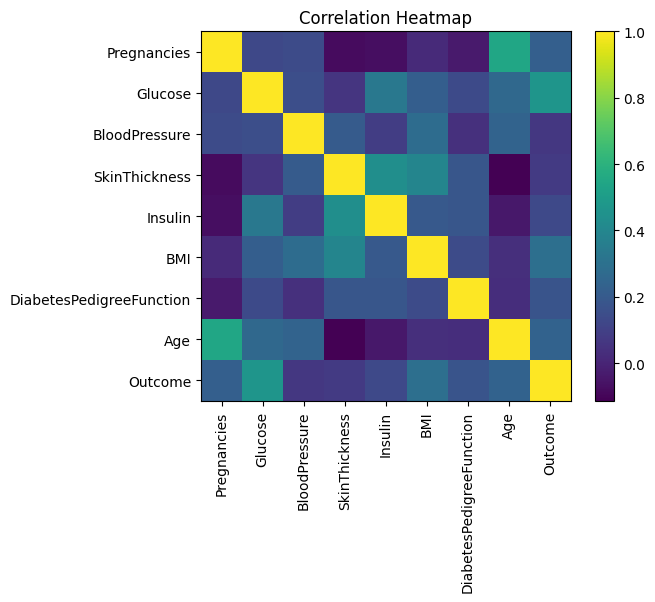

In [ ]:
corr = df.corr(numeric_only=True).values

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks(range(len(df.columns)), df.columns)
plt.title("Correlation Heatmap")
plt.show()


The heatmap shows how strongly each feature is related to another feature in the dataset.          
Darker or brighter colors mean a stronger relationship, which helps you understand which features affect diabetes the most.

In [ ]:
X = df.drop("Outcome",axis=1)
y = df["Outcome"]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
model_r = RandomForestClassifier(n_estimators=200)

In [ ]:
model_r.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200)

In [ ]:
y_pred_r = model_r.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_r))

Random Forest Accuracy: 0.7857142857142857


In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


0 = person does not have diabetes.
1 = person has diabetes.

In [ ]:
new_data = np.array([[0,137,40,35,168,43.1,2.288,33]])
prediction = model_r.predict(new_data)

if prediction[0] == 1:
    print("The person is NOT have Diabetes")
else:
    print("The person is have Diabetes")


The person is have Diabetes
